[[255 245 230 220 200]
 [230  10 160  30 180]
 [210 140 190 140 160]
 [ 20 170 210 170  40]
 [170  50  10  50 140]]
Shape: (5, 5)


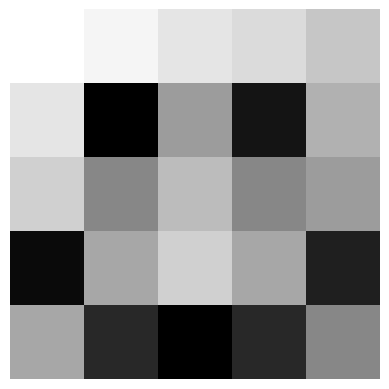

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

image = np.array(
[
    [255, 245, 230, 220, 200],
    [230,  10, 160,  30, 180],
    [210, 140, 190, 140, 160],
    [ 20, 170, 210, 170,  40],
    [170,  50,  10,  50, 140]
]
)

print(image)
print("Shape:", image.shape)

plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
pixels = np.array([
    [255, 0, 0],
    [0, 255, 0],
    [0, 0, 255],
    [255, 255, 0],
    [255, 0, 255],
    [0, 255, 255],
    [255, 255, 255],
    [0, 0, 0]
])
print(pixels)

[[255   0   0]
 [  0 255   0]
 [  0   0 255]
 [255 255   0]
 [255   0 255]
 [  0 255 255]
 [255 255 255]
 [  0   0   0]]


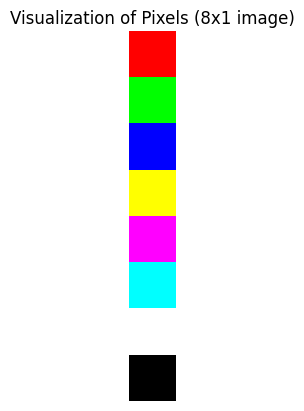

In [ ]:
plt.imshow(pixels.reshape(8,1,3))
plt.axis('off')
plt.title('Visualization of Pixels (8x1 image)')
plt.show()

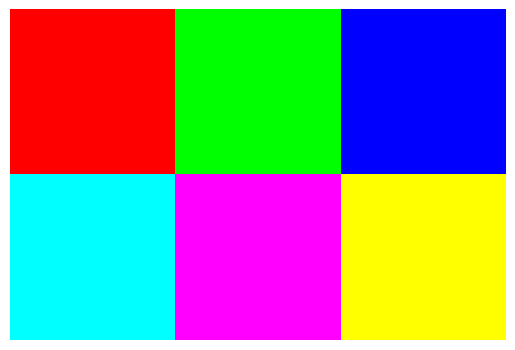

In [ ]:
grid = np.zeros((60, 90, 3), dtype=np.uint8)

# Top Row
grid[0:30, 0:30] = [255, 0, 0]  # Red
grid[0:30, 30:60] = [0, 255, 0]  # Green
grid[0:30, 60:90] = [0, 0, 255]  # Blue
# Bottom Row
grid[30:60, 0:30] = [0, 255, 255]
grid[30:60, 30:60] = [255, 0, 255]
grid[30:60, 60:90] = [255, 255, 0]

plt.imshow(grid)
plt.axis('off')
plt.show()

Saving Day5.jpg to Day5 (1).jpg


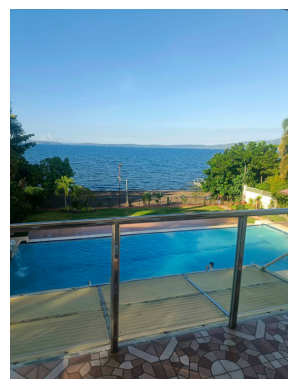

In [ ]:
from google.colab import files
from PIL import Image

uploaded = files.upload()
filename = list(uploaded.keys())[0]

image = Image.open(filename).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
image_array = np.array(image)

print("Array shape:", image_array.shape)
print("Number of dimensions:", image_array.ndim)

Array shape: (2048, 1536, 3)
Number of dimensions: 3


In [ ]:
y = 100
x = 200

pixel = image_array[y, x]
print("Pixel RGB:", pixel)

Pixel RGB: [ 84 156 214]



Five random pixel values:
Point (843, 830): RGB = [  7  84 126]
Point (837, 229): RGB = [13 54 36]
Point (522, 694): RGB = [153 209 246]
Point (1762, 419): RGB = [88 94 80]
Point (832, 200): RGB = [17 65 65]


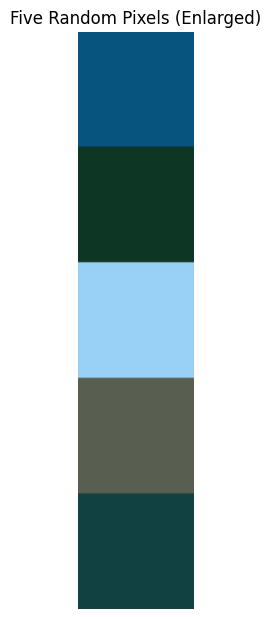

In [ ]:
import random

image_height, image_width, _ = image_array.shape

print("\nFive random pixel values:")
random_pixels_list = []
for i in range(5):
    random_y = random.randint(0, image_height - 1)
    random_x = random.randint(0, image_width - 1)
    random_pixel = image_array[random_y, random_x]
    random_pixels_list.append(random_pixel)
    print(f"Point ({random_y}, {random_x}): RGB = {random_pixel}")

# Visualize the found pixels
pixel_size = 50 # Enlarge each pixel to 50x50
display_height = len(random_pixels_list) * pixel_size
display_width = pixel_size
pixel_display = np.zeros((display_height, display_width, 3), dtype=np.uint8)

for i, pixel in enumerate(random_pixels_list):
    start_y = i * pixel_size
    end_y = (i + 1) * pixel_size
    pixel_display[start_y:end_y, 0:display_width] = pixel

plt.figure(figsize=(2, len(random_pixels_list) * 1.5))
plt.axis('off')
plt.title('Five Random Pixels (Enlarged)')
plt.show()

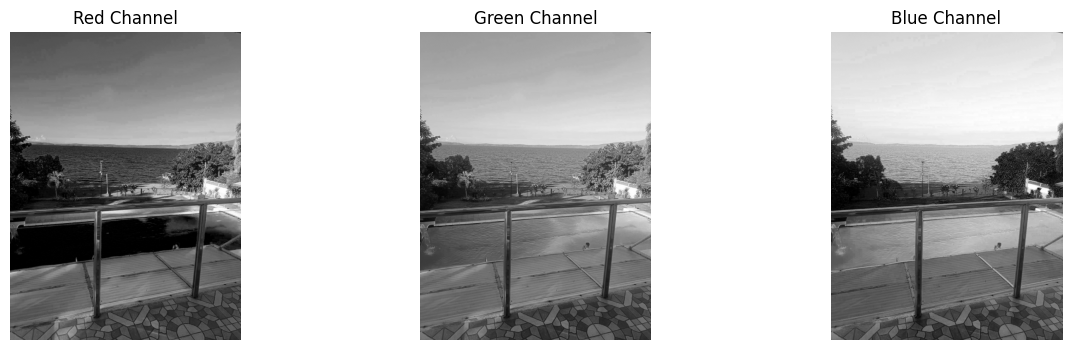

In [ ]:
R = image_array[:, :, 0]
G = image_array[:, :, 1]
B = image_array[:, :, 2]

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(R, cmap='gray')
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(G, cmap='gray')
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(B, cmap='gray')
plt.title("Blue Channel")
plt.axis("off")

plt.show()

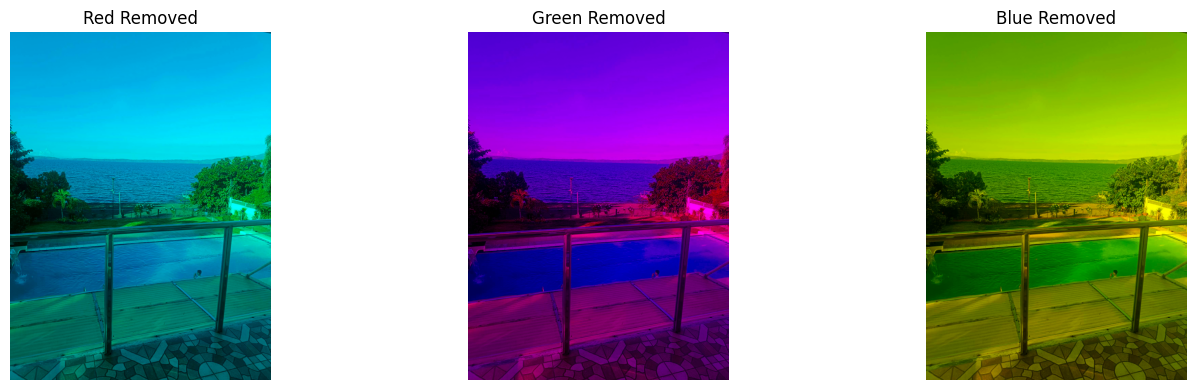

In [ ]:
no_red = image_array.copy()
no_red[:, :, 0] = 0

no_green = image_array.copy()
no_green[:, :, 1] = 0

no_blue = image_array.copy()
no_blue[:, :, 2] = 0

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.imshow(no_red)
plt.title("Red Removed")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(no_green)
plt.title("Green Removed")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(no_blue)
plt.title("Blue Removed")
plt.axis("off")

plt.tight_layout()
plt.show()

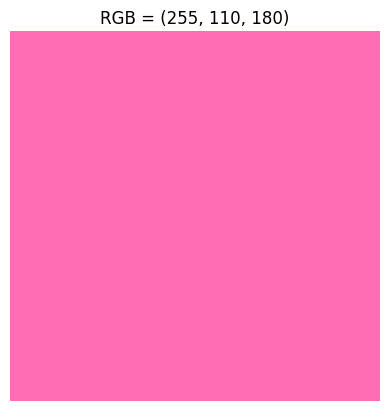

In [ ]:
def show_color(r, g, b):
    color = np.zeros((100, 100, 3), dtype=np.uint8)
    color[:, :] = [r, g, b]
    plt.imshow(color)
    plt.axis("off")
    plt.title(f"RGB = ({r}, {g}, {b})")
    plt.show()

show_color(255, 110, 180)

In [ ]:
import cv2
hsv_image = cv2.cvtColor(image_array, cv2.COLOR_RGB2HSV)

print("RGB:", image_array[100, 100])
print("HSV:", hsv_image[100, 100])

RGB: [ 84 156 214]
HSV: [103 155 214]


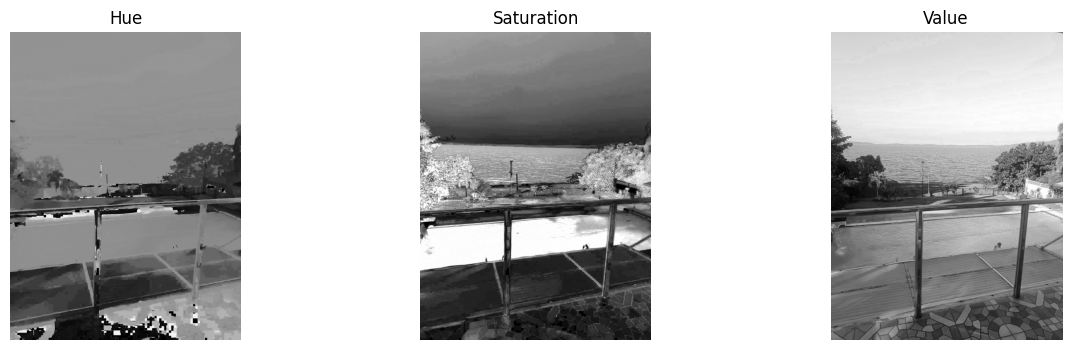

In [ ]:
H = hsv_image[:, :, 0]
S = hsv_image[:, :, 1]
V = hsv_image[:, :, 2]

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap='gray')
plt.title("Hue")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S, cmap='gray')
plt.title("Saturation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap='gray')
plt.title("Value")
plt.axis("off")

plt.show()

In [ ]:
# Change these coordinates to a point on the white object
y= 993
x=1351
print("RGB value:", image_array[y, x])

RGB value: [235 241 203]
